#  Customer Segmentation - Exploratory Data Analysis

##  Objective
The goal of this analysis is to understand how customers differ from each other in terms of behaviour and characteristics, in order to prepare for clustering.

##  Business Context
Customer segmentation allows businesses to group customers based on behaviour, enabling:
- targeted marketing
- personalised offers
- improved customer retention

This analysis focuses on identifying patterns that will support meaningful customer segmentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Data/processed/online_retail_cleaned.csv")

In [3]:
print("Unique Customers:", df["customerid"].nunique())
print("Total Transactions:", df["invoiceno"].nunique())
print("Total Revenue:", df["total_price"].sum())

Unique Customers: 4338
Total Transactions: 18532
Total Revenue: 8887208.894000001


## Numerical Feature Analysis

We analyse the distribution of numerical variables to understand variation in customer behaviour.

###  Key Questions
- Do customers have similar or very different values?
- Are there clear high-value vs low-value groups?

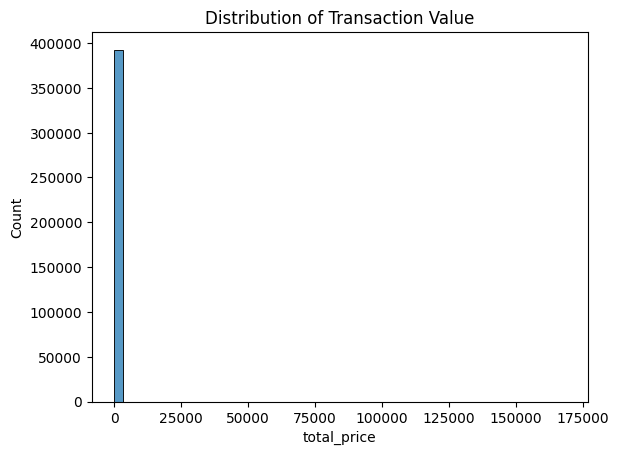

In [4]:
plt.figure()
sns.histplot(df["total_price"], bins =50)
plt.title("Distribution of Transaction Value")
plt.show()

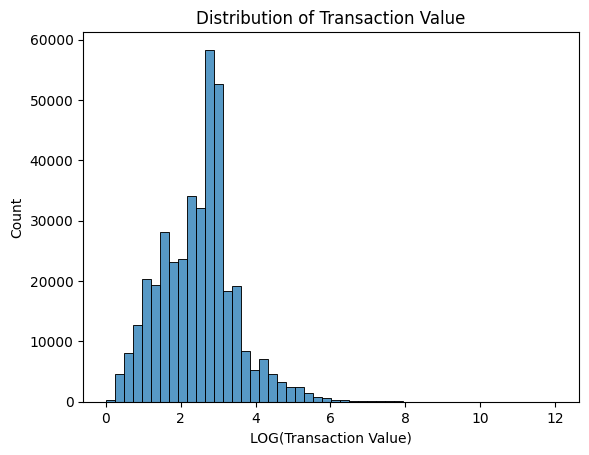

In [6]:
plt.figure()
sns.histplot(np.log1p(df["total_price"]), bins =50)
plt.title("Distribution of Transaction Value")
plt.xlabel("LOG(Transaction Value)")
plt.show()

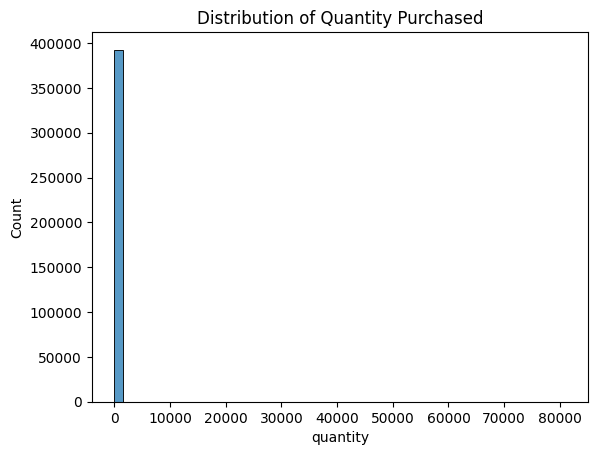

In [8]:
plt.figure()
sns.histplot(df["quantity"], bins =50)
plt.title("Distribution of Quantity Purchased")
plt.show()

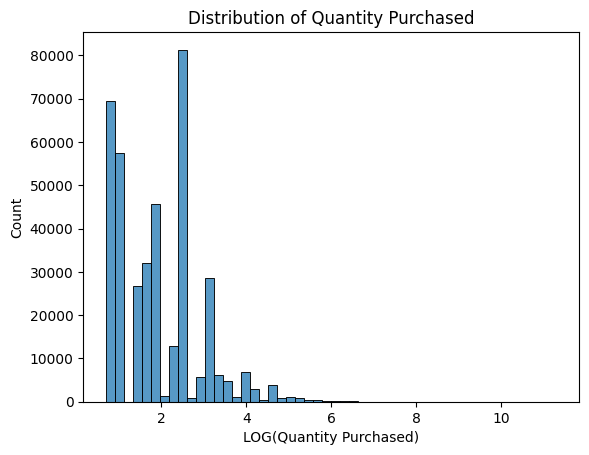

In [9]:
plt.figure()
sns.histplot(np.log1p(df["quantity"]), bins =50)
plt.title("Distribution of Quantity Purchased")
plt.xlabel("LOG(Quantity Purchased)")
plt.show()

### Insight
The variation in numerical features suggests that customers behave differently, particularly in terms of value and engagement.

This indicates that clustering can separate customers into distinct groups based on these variables.

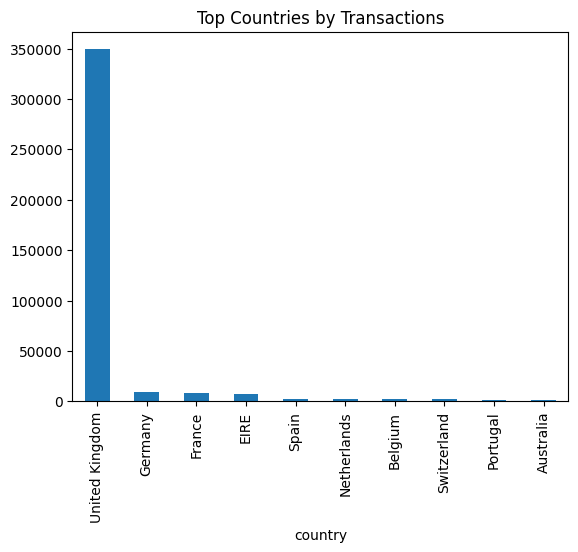

In [10]:
top_countries = df["country"].value_counts().head(10)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top Countries by Transactions")
plt.show()

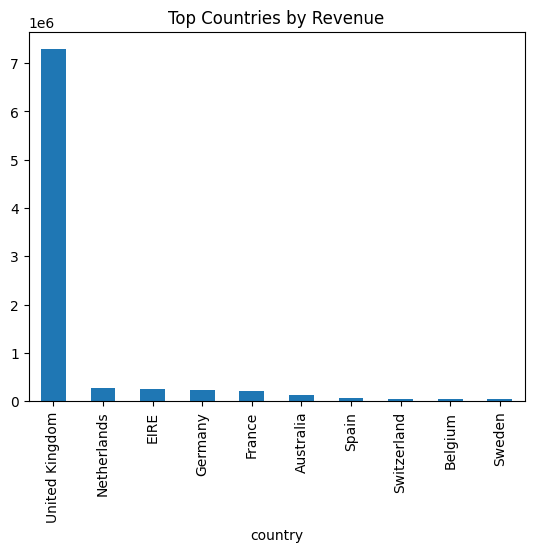

In [11]:
country_revenue = df.groupby("country")["total_price"].sum().sort_values(ascending=False).head(10)

plt.figure()
country_revenue.plot(kind="bar")
plt.title("Top Countries by Revenue")
plt.show()

In [12]:
customer_df = df.groupby("customerid").agg({
    "total_price":"sum",
    "invoiceno":"nunique",
    "quantity": "sum"
}).reset_index()
customer_df.columns =["customerid","total_spend", "num_orders","total_items"]

customer_df.head()

,customerid,total_spend,num_orders,total_items
0,12346,77183.60,1,74215
1,12347,4310.00,7,2458
2,12348,1797.24,4,2341
3,12349,1757.55,1,631
4,12350,334.40,1,197


##  Customer Value Analysis

We explore variables related to customer value, such as spending or usage.

###  Key Questions
- Are there high-value and low-value customers?
- Is spending evenly distributed or skewed?

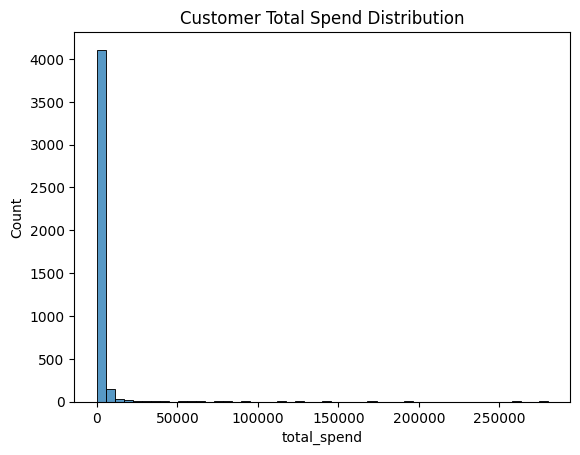

In [13]:
plt.figure()
sns.histplot(customer_df['total_spend'],bins=50)
plt.title("Customer Total Spend Distribution")
plt.show()

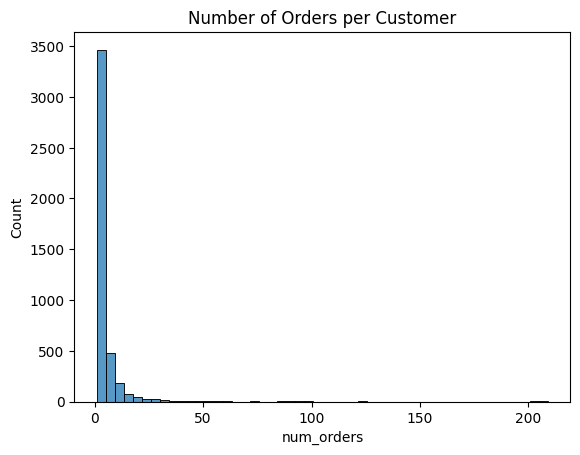

In [14]:
plt.figure()
sns.histplot(customer_df["num_orders"], bins =50)
plt.title("Number of Orders per Customer")
plt.show()

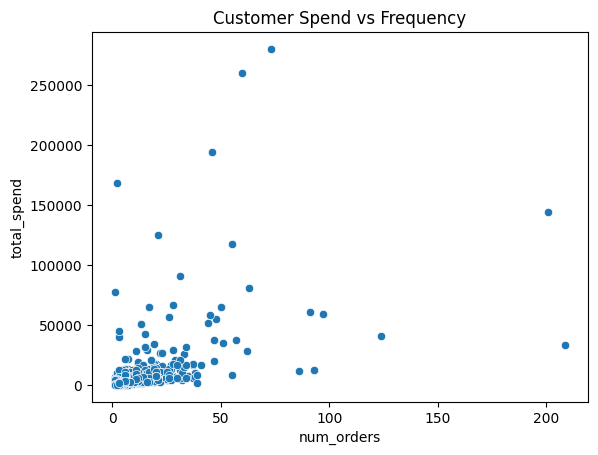

In [15]:
plt.figure()
sns.scatterplot(
    x='num_orders',
    y='total_spend',
    data = customer_df
)
plt.title("Customer Spend vs Frequency")
plt.show()

## 4. Feature Relationships

We analyse relationships between variables to identify patterns in customer behaviour.

###  Key Questions
- Do certain behaviours occur together?
- Are there natural groupings in the data?

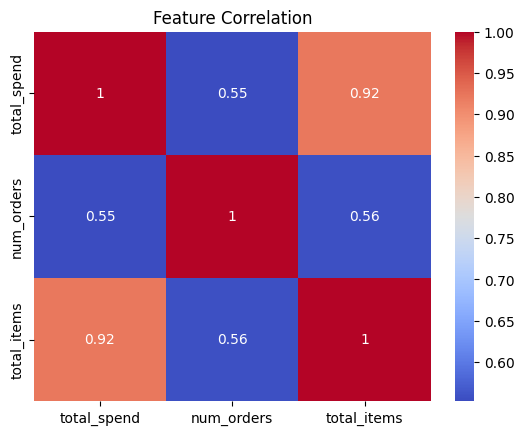

In [16]:
corr = customer_df.drop("customerid", axis=1).corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

###  Insight
Relationships between variables indicate that some customer behaviours are linked, which will help clustering algorithms identify meaningful segments.

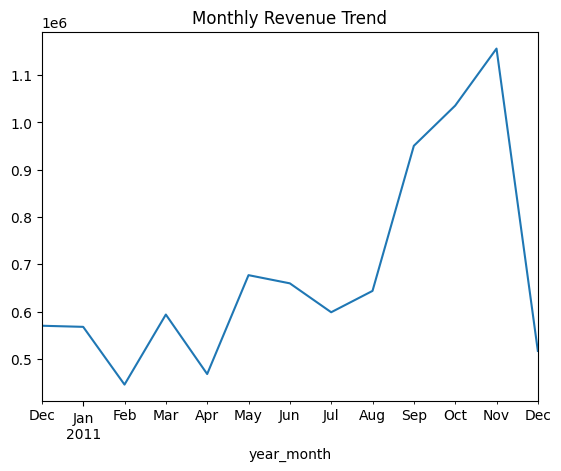

In [17]:
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

df["year_month"] = df["invoicedate"].dt.to_period("M")
monthly_revenue = df.groupby("year_month")["total_price"].sum()

monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.show()

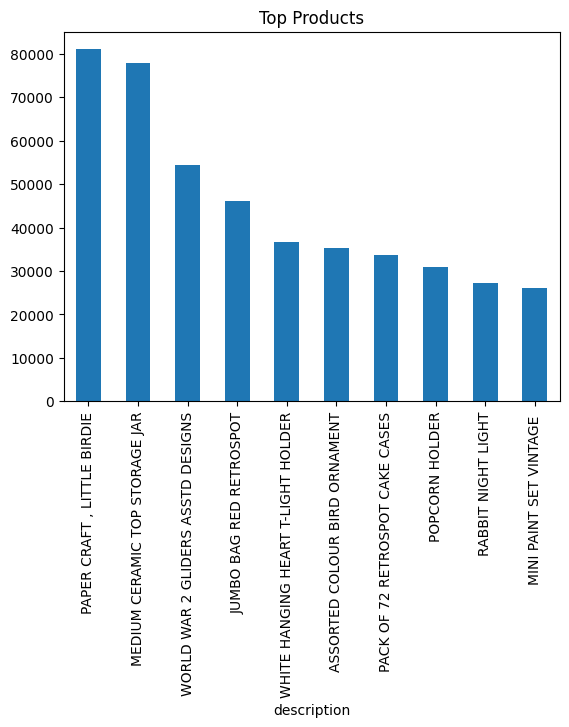

In [18]:
top_products = df.groupby("description")["quantity"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar")
plt.title("Top Products")
plt.show()

## Implications for Segmentation

From this analysis:

- Customers show clear variation in behaviour
- Some features indicate strong differences between customers
- Certain variables may dominate clustering if not scaled

These insights will guide:
- feature selection
- feature scaling
- clustering approach

## Key Insights

- Customers differ significantly in behaviour and value
- Some customers exhibit much higher engagement or spending
- Relationships between variables suggest natural groupings
- Outliers may impact clustering results

## Business Implications

- High-value customers can be identified and targeted
- Low-engagement customers may need re-engagement strategies
- Segmentation enables more personalised marketing

## Next Steps

- Create behavioural features for clustering
- Scale features appropriately
- Apply clustering algorithms (e.g. KMeans)
- Profile and interpret customer segments

## Conclusion

This analysis confirms that customers are not homogeneous and can be grouped into distinct segments based on behaviour, making clustering a suitable approach.